In [1]:
import sys
sys.path.append('/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach')
from inf_step_exp.mc_approach.simulate import AMMSimulator

path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach/crazy_simulation_results/20250410_011107'
# AMMSimulator.combine_chunks(path, delete_chunks=False)

In [22]:
import pandas as pd

path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach/crazy_simulation_results/20250521_145256/simulation_results_combined.parquet'
diff_df = pd.read_parquet(path)
print(diff_df.columns)

Index(['seed_idx', 'sigma', 'gamma', 'price', 'x_dis', 'y_dis', 'x_rinc',
       'y_rinc', 'x_rout', 'y_rout', 'dis_inc_fees', 'dis_out_fees'],
      dtype='object')


In [23]:
initial_value = 200
diff_df['vout_dis'] = diff_df['x_dis'] * diff_df['price'] + diff_df['y_dis'] + diff_df['dis_out_fees'] - initial_value
diff_df['vinc_dis'] = diff_df['x_dis'] * diff_df['price'] + diff_df['y_dis'] + diff_df['dis_inc_fees'] - initial_value
diff_df['vout_re'] = diff_df['x_rout'] * diff_df['price'] + diff_df['y_rout'] - initial_value
diff_df['vinc_re'] = diff_df['x_rinc'] * diff_df['price'] + diff_df['y_rinc'] - initial_value
diff_df['diff_dis_out_in'] = diff_df['vout_dis'] - diff_df['vinc_dis']
diff_df['diff_re_out_in'] = diff_df['vout_re'] - diff_df['vinc_re']
diff_df['diff_dis_out_re_out'] = diff_df['vout_dis'] - diff_df['vout_re']
diff_df['diff_dis_in_re_in'] = diff_df['vinc_dis'] - diff_df['vinc_re']

In [24]:
from scipy.stats import norm
import numpy as np

# Create a table of results
print("\nStrategy Performance Results:")
print("-" * 70)
print(f"{'Strategy':<15} {'Mean Value':<15} {'Std Dev':<15} {'P-value':<15}")
print("-" * 70)

# Calculate statistics for each strategy
strategies = {
    'Distribute Out': ('vout_dis', 'Distribute Outgoing'),
    'Distribute In': ('vinc_dis', 'Distribute Incoming'),
    'Rebalance Out': ('vout_re', 'Rebalance Outgoing'),
    'Rebalance In': ('vinc_re', 'Rebalance Incoming')
}

for strategy, (col, label) in strategies.items():
    mean_val = diff_df[col].mean()
    std_val = diff_df[col].std()
    p_val = 1 - norm.cdf((mean_val - initial_value)/(std_val/np.sqrt(10000)))
    print(f"{label:<15} {mean_val:<15.4f} {std_val:<15.4f} {p_val:<15.4f}")

print("-" * 70)

# Print the difference comparisons
print("\nDifference Comparisons:")
print("-" * 70)
print(f"{'Comparison':<25} {'Mean Difference':<15} {'Std Dev':<15}")
print("-" * 70)

diffs = {
    'Distribute Out-In': 'diff_dis_out_in',
    'Rebalance Out-In': 'diff_re_out_in',
    'Distribute-Rebalance Out': 'diff_dis_out_re_out',
    'Distribute-Rebalance In': 'diff_dis_in_re_in'
}

for label, col in diffs.items():
    mean_diff = diff_df[col].mean()
    std_diff = diff_df[col].std()
    print(f"{label:<25} {mean_diff:<15.4f} {std_diff:<15.4f}")

print("-" * 70)


Strategy Performance Results:
----------------------------------------------------------------------
Strategy        Mean Value      Std Dev         P-value        
----------------------------------------------------------------------
Distribute Outgoing -0.2698         25.0317         1.0000         
Distribute Incoming -0.2718         25.0316         1.0000         
Rebalance Outgoing -0.2710         25.1164         1.0000         
Rebalance Incoming -0.2730         25.1161         1.0000         
----------------------------------------------------------------------

Difference Comparisons:
----------------------------------------------------------------------
Comparison                Mean Difference Std Dev        
----------------------------------------------------------------------
Distribute Out-In         0.0020          0.0002         
Rebalance Out-In          0.0020          0.0003         
Distribute-Rebalance Out  0.0012          0.0983         
Distribute-Rebalance In

In [19]:
from scipy.stats import norm
import numpy as np

mean_vout_dis = diff_df['vout_dis'].mean()
std_vout_dis = diff_df['vout_dis'].std()
p_vout_dis = 1 - norm.cdf((mean_vout_dis - 200)/(std_vout_dis/np.sqrt(10000)))
print(p_vout_dis)
print(f"average value for distribute outgoing is {mean_vout_dis}")

0.8594369236848298
average value for distribute outgoing is 199.73021030318597


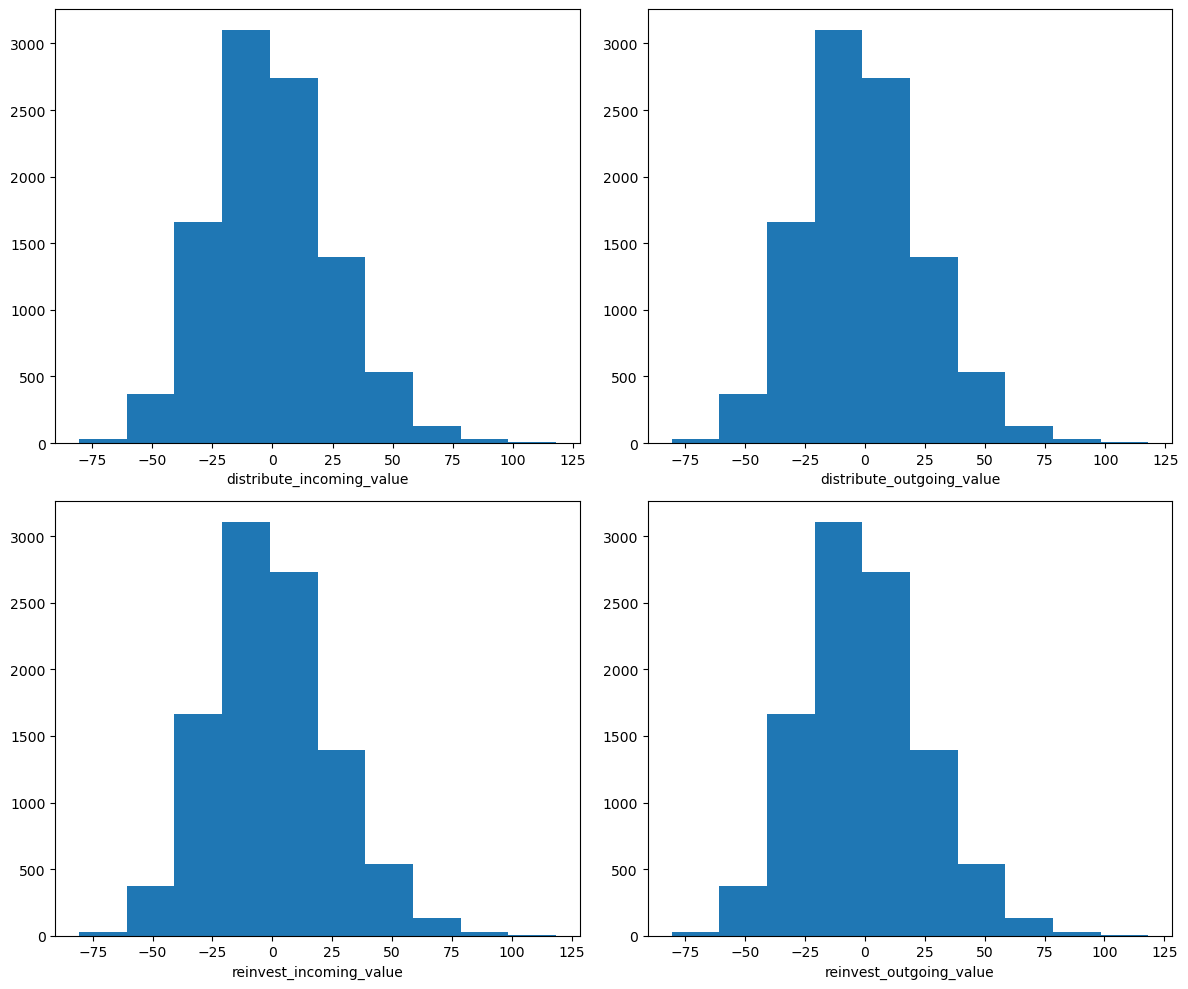

In [9]:
import matplotlib.pyplot as plt

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot histograms
axes[0, 0].hist(diff_df['vinc_dis'])
axes[0, 0].set_xlabel('distribute_incoming_value')

axes[0, 1].hist(diff_df['vout_dis'])
axes[0, 1].set_xlabel('distribute_outgoing_value')

axes[1, 0].hist(diff_df['vinc_re'])
axes[1, 0].set_xlabel('reinvest_incoming_value')

axes[1, 1].hist(diff_df['vout_re'])
axes[1, 1].set_xlabel('reinvest_outgoing_value')

plt.tight_layout()
plt.show()


Results:
Strategy      Mean  Std Error  P-value
      DI -0.053015   0.248373 0.584511
      DO -0.051034   0.248374 0.581399
      RI  1.249737   0.250854 0.000000
      RO -1.211623   0.245961 1.000000


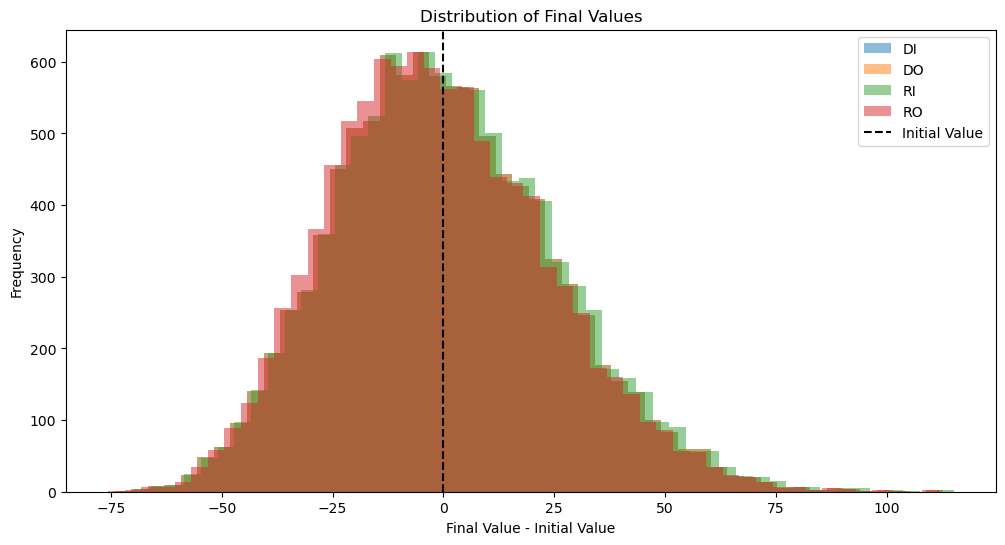

In [ ]:
import numpy as np
from scipy.stats import norm

# Parameters
SIM = int(1e4)
r = 0
sigma = 0.25
dt = 1 / 10000
T = np.arange(0, 1 + dt, dt)
gamma = 0.01

# Random walk
Z = np.random.randn(SIM, len(T) - 1)
W = np.sqrt(dt) * np.cumsum(Z, axis=1)
W = np.hstack([np.zeros((SIM, 1)), W])
P = np.exp((r - 0.5 * sigma ** 2) * T + sigma * W)

# Initialize values
xDI = np.full(SIM, 100.0)
yDI = np.full(SIM, 100.0)
fDI = np.zeros(SIM)
xDO = np.full(SIM, 100.0)
yDO = np.full(SIM, 100.0)
fDO = np.zeros(SIM)
xRI = np.full(SIM, 100.0)
yRI = np.full(SIM, 100.0)
xRO = np.full(SIM, 100.0)
yRO = np.full(SIM, 100.0)

# Simulation loop
for t in range(1, len(T)):
    Pt = P[:, t]
    
    # DI case
    L = np.sqrt(xDI * yDI)
    indx = Pt > 1 / (1 - gamma) * (yDI / xDI)
    indy = Pt < (1 - gamma) * (yDI / xDI)
    ind0 = ~(indx | indy)

    x = np.where(indx, L / np.sqrt((1 - gamma) * Pt),
        np.where(indy, L * np.sqrt((1 - gamma) / Pt), xDI))
    y = np.where(indx, L * np.sqrt((1 - gamma) * Pt),
        np.where(indy, L * np.sqrt(Pt / (1 - gamma)), yDI))
    
    dx = x - xDI
    dy = y - yDI
    xDI = x
    yDI = y
    fDI[indx] += gamma / (1 - gamma) * dy[indx]
    fDI[indy] += gamma / (1 - gamma) * Pt[indy] * dx[indy]

    # DO case
    L = np.sqrt(xDO * yDO)
    indx = Pt > 1 / (1 - gamma) * (yDO / xDO)
    indy = Pt < (1 - gamma) * (yDO / xDO)
    ind0 = ~(indx | indy)

    x = np.where(indx, L / np.sqrt((1 - gamma) * Pt),
        np.where(indy, L * np.sqrt((1 - gamma) / Pt), xDO))
    y = np.where(indx, L * np.sqrt((1 - gamma) * Pt),
        np.where(indy, L * np.sqrt(Pt / (1 - gamma)), yDO))

    dx = x - xDO
    dy = y - yDO
    xDO = x
    yDO = y
    fDO[indx] -= gamma * Pt[indx] * dx[indx]
    fDO[indy] -= gamma * dy[indy]

    # RI case
    L = np.sqrt(xRI * yRI)
    indx = Pt > 1 / (1 - gamma) * (yRI / xRI)
    indy = Pt < (1 - gamma) * (yRI / xRI)
    x = xRI.copy()
    y = yRI.copy()

    x[indy] = (gamma * Pt[indy] * xRI[indy] + np.sqrt(gamma ** 2 * Pt[indy] ** 2 * xRI[indy] ** 2 + 4 * (1 + gamma) * Pt[indy] * L[indy] ** 2)) / (2 * (1 + gamma) * Pt[indy])
    y[indx] = (gamma * yRI[indx] + np.sqrt(gamma ** 2 * yRI[indx] ** 2 + 4 * (1 + gamma) * Pt[indx] * L[indx] ** 2)) / (2 * (1 + gamma))
    x[indx] = L[indx] ** 2 / y[indx]
    y[indy] = L[indy] ** 2 / x[indy]

    xRI = x + gamma * (x - xRI) * indy
    yRI = y + gamma * (y - yRI) * indx

    # RO case
    L = np.sqrt(xRO * yRO)
    indx = Pt > 1 / (1 - gamma) * (yRO / xRO)
    indy = Pt < (1 - gamma) * (yRO / xRO)
    x = xRO.copy()
    y = yRO.copy()

    x[indx] = (gamma * Pt[indx] * xRO[indx] + np.sqrt(gamma ** 2 * Pt[indx] ** 2 * xRO[indx] ** 2 + 4 * (1 - gamma) * Pt[indx] * L[indx] ** 2)) / (2 * (1 - gamma) * Pt[indx])
    y[indy] = (gamma * yRO[indy] + np.sqrt(gamma ** 2 * yRO[indy] ** 2 + 4 * (1 - gamma) * L[indy] ** 2)) / (2 * (1 - gamma))
    x[indy] = L[indy] ** 2 / y[indy]
    y[indx] = L[indx] ** 2 / x[indx]

    xRO = x - gamma * (x - xRO) * indx
    yRO = y - gamma * (y - yRO) * indy

# Final values
vDI = P[:, -1] * xDI + yDI + fDI
vDO = P[:, -1] * xDO + yDO + fDO
vRI = P[:, -1] * xRI + yRI
vRO = P[:, -1] * xRO + yRO

# Output results
means = np.array([vDI.mean(), vDO.mean(), vRI.mean(), vRO.mean()]) - 200
std_err = np.array([vDI.std(), vDO.std(), vRI.std(), vRO.std()]) / np.sqrt(SIM)
p_values = 1 - norm.cdf([
    (vDI.mean() - 200) / (vDI.std() / np.sqrt(SIM)),
    (vDO.mean() - 200) / (vDO.std() / np.sqrt(SIM)),
    (vRI.mean() - 200) / (vRI.std() / np.sqrt(SIM)),
    (vRO.mean() - 200) / (vRO.std() / np.sqrt(SIM)),
])




Results:
Strategy      Mean  Std Error  P-value
      DI -0.053015   0.248373 0.584511
      DO -0.051034   0.248374 0.581399
      RI  1.249737   0.250854 0.000000
      RO -1.211623   0.245961 1.000000


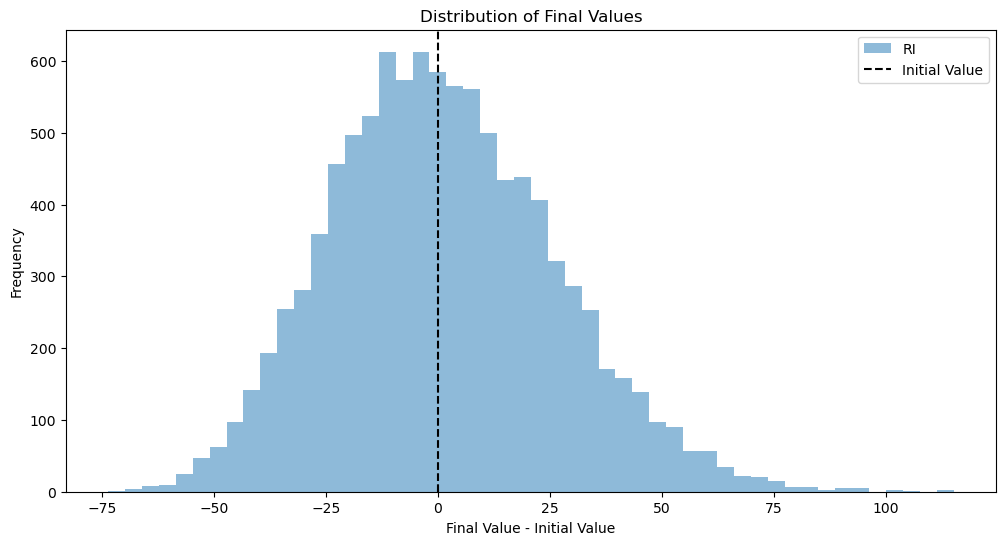

In [13]:
# Display results
import pandas as pd

results = pd.DataFrame({
    'Strategy': ['DI', 'DO', 'RI', 'RO'],
    'Mean': means,
    'Std Error': std_err,
    'P-value': p_values
})

print("\nResults:")
print(results.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# Optional: Plot the distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# plt.hist(vDI - 200, bins=50, alpha=0.5, label='DI')
# plt.hist(vDO - 200, bins=50, alpha=0.5, label='DO')
plt.hist(vRI - 200, bins=50, alpha=0.5, label='RI')
# plt.hist(vRO - 200, bins=50, alpha=0.5, label='RO')
plt.axvline(x=0, color='black', linestyle='--', label='Initial Value')
plt.xlabel('Final Value - Initial Value')
plt.ylabel('Frequency')
plt.title('Distribution of Final Values')
plt.legend()
plt.show()

In [53]:
import pandas as pd

path = '/home/shiftpub/Dynamic_AMM/inf_step_exp/mc_approach/crazy_simulation_results/20250522_222200/simulation_full_history_steps_100.parquet'


df = pd.read_parquet(path)
df.loc[:, 'cum_aDI'] = df.loc[:, 'aDI'].cumsum()
df.loc[:, 'cum_aDO'] = df.loc[:, 'aDO'].cumsum()
df.loc[:, 'cum_aRI'] = df.loc[:, 'aRI'].cumsum()
df.loc[:, 'cum_aRO'] = df.loc[:, 'aRO'].cumsum()
print(df.columns)

# sort df by t, mu, sigma, and gamma

df.sort_values(by=['mu', 'sigma', 'gamma', 't'], inplace=True)

df.to_csv('simulation_full_history_steps_100.csv', index=False)


Index(['t', 'mu', 'sigma', 'gamma', 'p', 'xD', 'yD', 'fDI', 'fDO', 'xRI',
       'yRI', 'xRO', 'yRO', 'vDI', 'vDO', 'vRI', 'vRO', 'aDI', 'aDO', 'aRI',
       'aRO', 'cum_aDI', 'cum_aDO', 'cum_aRI', 'cum_aRO'],
      dtype='object')


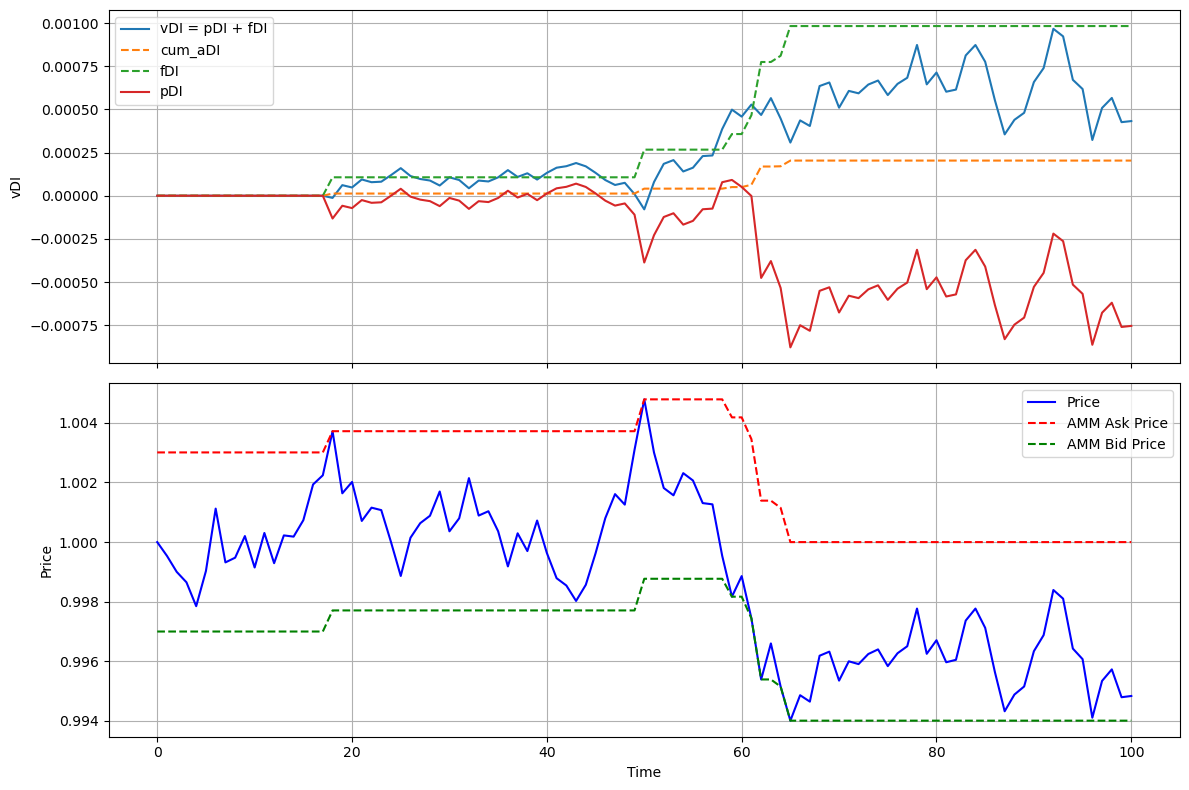

In [65]:
import matplotlib.pyplot as plt

# Create figure with 1x2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Filter data for first 20 time steps
selected_df = df[(df['mu'] == -1) & (df['sigma'] == 0.1) & (df['gamma'] == 0.003)]

# Upper plot: vDI
ax1.plot(selected_df['t'], selected_df['vDI'], label='vDI = pDI + fDI')
ax1.plot(selected_df['t'], selected_df['cum_aDI'], label='cum_aDI', linestyle='--')
ax1.plot(selected_df['t'], selected_df['fDI'], label='fDI', linestyle='--')
ax1.plot(selected_df['t'], selected_df['vDI'] - selected_df['cum_aDI'] - selected_df['fDI'], label='pDI')
ax1.set_ylabel('vDI')
ax1.grid(True)
ax1.legend()

# Lower plot: Price and AMM prices
ax2.plot(selected_df['t'], selected_df['p'], label='Price', color='blue')
ax2.plot(selected_df['t'], selected_df['yRI']/selected_df['xRI']/(1-selected_df['gamma']), 
         '--', label='AMM Ask Price', color='red')
ax2.plot(selected_df['t'], selected_df['yRI']/selected_df['xRI']*(1-selected_df['gamma']), 
         '--', label='AMM Bid Price', color='green')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

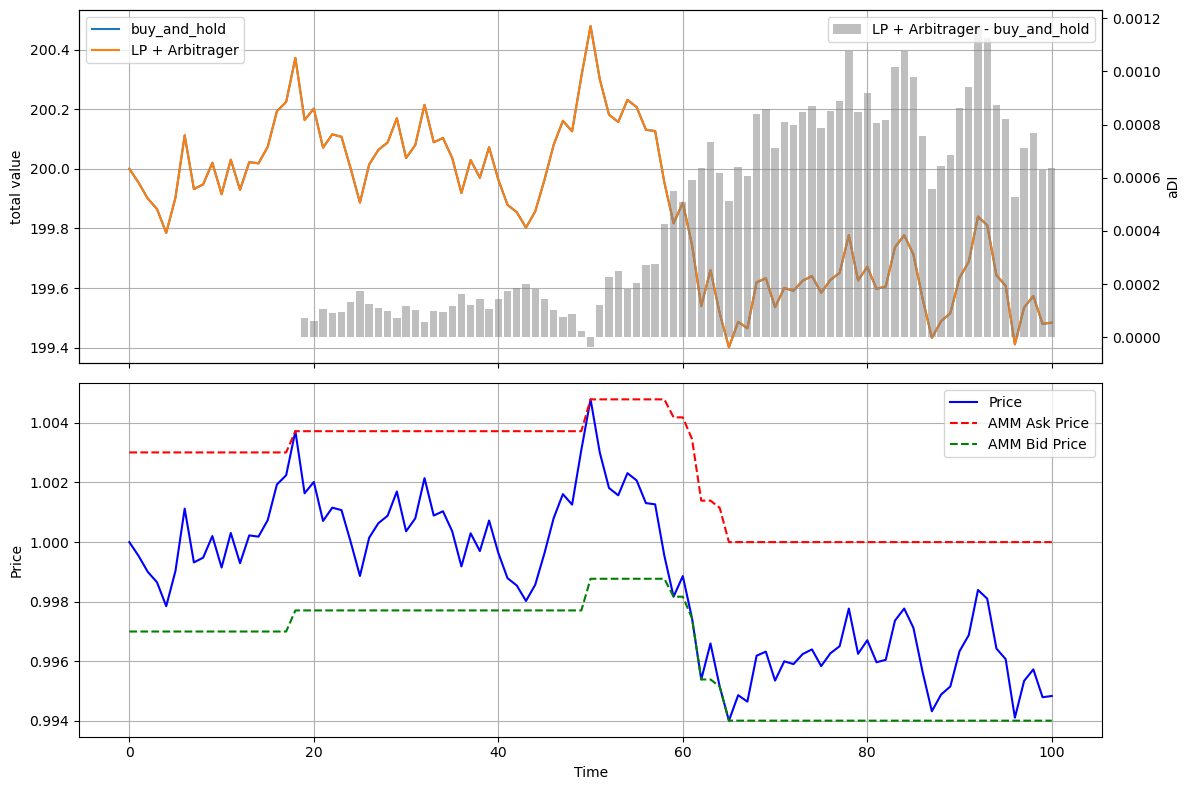

In [72]:
# Create figure with 1x2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Filter data for first 20 time steps
selected_df = df[(df['mu'] == -1) & (df['sigma'] == 0.1) & (df['gamma'] == 0.003)]

# Upper plot: vDI
ax1.plot(selected_df['t'], 100 * selected_df['p'] + 100, label='buy_and_hold')
ax1.plot(selected_df['t'], selected_df['xD'] * selected_df['p'] + selected_df['yD'] + selected_df['fDI'] + selected_df['cum_aDI'], label='LP + Arbitrager')
ax1.set_ylabel('total value')
ax1.grid(True)
ax1.legend(loc='upper left')

# Create secondary y-axis for the bar plot
ax1_twin = ax1.twinx()
ax1_twin.bar(selected_df['t'], selected_df['xD'] * selected_df['p'] + selected_df['yD'] + selected_df['fDI'] + selected_df['cum_aDI'] - 100 * selected_df['p'] - 100, 
             label='LP + Arbitrager - buy_and_hold', alpha=0.5, color='gray')
ax1_twin.set_ylabel('aDI')
ax1_twin.legend(loc='upper right')

# Lower plot: Price and AMM prices
ax2.plot(selected_df['t'], selected_df['p'], label='Price', color='blue')
ax2.plot(selected_df['t'], selected_df['yRI']/selected_df['xRI']/(1-selected_df['gamma']), 
         '--', label='AMM Ask Price', color='red')
ax2.plot(selected_df['t'], selected_df['yRI']/selected_df['xRI']*(1-selected_df['gamma']), 
         '--', label='AMM Bid Price', color='green')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()